# Sketched Normal-Operator Products

Given a low-rank iterate $X = U \operatorname{diag}(\sigma) V^T$ and the cryo-EM forward model,
we compute $S_L G(X)$ and $G(X) Q_R$ without forming the dense gradient
$G(X) = A^*(A(X) - b)$.

**Sections:**
1. Generate / load PDB dataset + visualize GT states
2. Sanity: $X = X_{GT} \Rightarrow G(X) \approx 0$ (+ tiny noise verification)
3. Sketch at scale: timing vs sketch_rank
4. PPCA EM baseline + relvar comparison

In [1]:
import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr

warnings.filterwarnings('ignore', module='finufft')
warnings.filterwarnings('ignore', category=FutureWarning)

import recovar.core.fourier_transform_utils as ftu
from recovar import utils
from recovar.core import linalg
from recovar.output import metrics
from recovar.simulation import simulator
from recovar.simulation.trajectory_generation import generate_trajectory_volumes
from recovar.ppca.ppca_scale_sweep import _load_simulated_dataset, _with_trailing_separator
from recovar.ppca import ppca as ppca_mod, prior_estimation
from recovar.ppca.sketched_normal import compute_normal_residual_sketches

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
print(f'JAX devices: {jax.devices()}')

def to_real(vol_ft, vs):
    return np.asarray(ftu.get_idft3(np.asarray(vol_ft).reshape(vs)).real)

def plot_slices(vols_real, labels, title):
    n = len(vols_real)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    if n == 1: axes = [axes]
    for i, (v, l) in enumerate(zip(vols_real, labels)):
        mid = v.shape[2] // 2
        im = axes[i].imshow(v[:, :, mid], cmap='gray')
        axes[i].set_title(l, fontsize=9); axes[i].axis('off')
        plt.colorbar(im, ax=axes[i], fraction=0.046)
    fig.suptitle(title, fontsize=11); fig.tight_layout(); plt.show()

JAX devices: [CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3)]


In [2]:
GRID_SIZE   = 128
N_IMAGES    = 100000
NOISE_LEVEL = 0.1
N_VOLUMES   = 10
N_PCS       = 10
SKETCH_RANK = 200
BATCH_SIZE  = 500
PPCA_ITERS  = 10
DISC_TYPE   = 'linear_interp'

BASE_DIR = '/scratch/gpfs/GILLES/mg6942/tmp/sketch_notebook'
os.makedirs(BASE_DIR, exist_ok=True)

## 1. Generate / Load Dataset

Real-space volumes from PDB 5nrl (spliceosome) via rigid-body subcomplex rotation,
then simulated cryo-EM images (Fourier projection + CTF + noise).

In [3]:
voxel_size = 4.25 * 128 / GRID_SIZE
vol_prefix = os.path.join(BASE_DIR, 'generated_volumes', 'vol')
ds_dir = os.path.join(BASE_DIR, 'test_dataset')

if not os.path.isfile(f'{vol_prefix}0000.mrc'):
    print(f'Generating {N_VOLUMES} trajectory volumes (grid={GRID_SIZE}) ...')
    generate_trajectory_volumes(
        BASE_DIR, grid_size=GRID_SIZE, n_volumes=N_VOLUMES,
        voxel_size=voxel_size, Bfactor=80, max_rotation_degrees=10.0,
    )
else:
    print(f'Reusing volumes at {vol_prefix}')

if not os.path.isfile(os.path.join(ds_dir, f'particles.{GRID_SIZE}.mrcs')):
    print(f'Simulating dataset: n={N_IMAGES}, noise={NOISE_LEVEL} ...')
    np.random.seed(42)
    simulator.generate_synthetic_dataset(
        ds_dir, voxel_size, vol_prefix, N_IMAGES,
        grid_size=GRID_SIZE, noise_level=NOISE_LEVEL, noise_model='radial1',
        contrast_std=0.0, noise_scale_std=0.0,
        dataset_params_option='uniform', disc_type=DISC_TYPE,
        trailing_zero_format_in_vol_name=True,
        put_extra_particles=False, percent_outliers=0.0,
    )
else:
    print(f'Reusing dataset at {ds_dir}')

cryo, sim_info, gt, noise_var = _load_simulated_dataset(
    _with_trailing_separator(ds_dir), GRID_SIZE, N_IMAGES, lazy=False,
)
vs = cryo.volume_shape
half_vs = ftu.volume_shape_to_half_volume_shape(vs)
half_vol_size = int(np.prod(half_vs))
vol_size = int(np.prod(vs))
n_images = cryo.n_images
print(f'Loaded: grid={cryo.grid_size}, n_images={n_images}')

Reusing volumes at /scratch/gpfs/GILLES/mg6942/tmp/sketch_notebook/generated_volumes/vol
Reusing dataset at /scratch/gpfs/GILLES/mg6942/tmp/sketch_notebook/test_dataset


Loaded: grid=128, n_images=100000


### GT conformational states

The trajectory has `N_VOLUMES` discrete states from rigid-body rotation of the
5nrl spliceosome subcomplexes. Central z-slices:

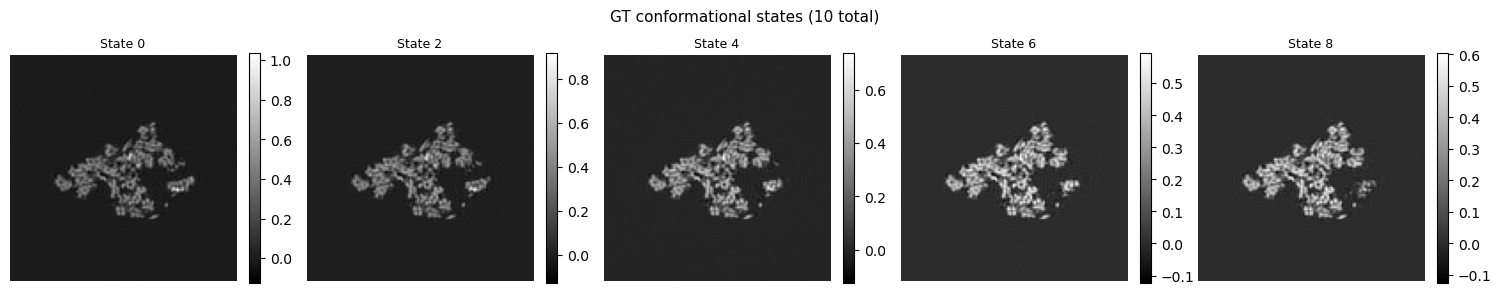

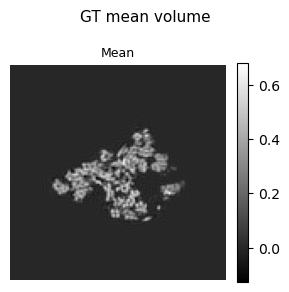

In [4]:
# Show a selection of GT states
n_show = min(5, gt.volumes.shape[0])
step = max(1, gt.volumes.shape[0] // n_show)
idx = list(range(0, gt.volumes.shape[0], step))[:n_show]
plot_slices(
    [to_real(gt.volumes[i], vs) for i in idx],
    [f'State {i}' for i in idx],
    f'GT conformational states ({N_VOLUMES} total)',
)

# Mean
gt_mean = gt.get_mean()
plot_slices([to_real(gt_mean, vs)], ['Mean'], 'GT mean volume')

In [5]:
# GT eigenvectors and true per-image coordinates
U_gt_all, s_gt_all, _ = gt.get_vol_svd()
U_gt = U_gt_all[:, :N_PCS]
s_gt = s_gt_all[:N_PCS]

U_gt_half = np.asarray(ftu.full_volume_to_half_volume(U_gt.T, vs).T)
mean_half = np.asarray(ftu.full_volume_to_half_volume(gt_mean.reshape(vs), vs).reshape(-1))

assign = np.array(sim_info['image_assignment'])
centered_vols = np.asarray(gt.volumes - gt_mean[None, :])
state_coords = (np.conj(centered_vols) @ np.asarray(U_gt)) / np.asarray(s_gt)
V_true = state_coords[assign].real.astype(np.float32)

print(f'GT: {N_PCS} PCs, top eigenvalues: {s_gt[:5]}')
print(f'V_true shape: {V_true.shape}')

GT: 10 PCs, top eigenvalues: [13924.68072531  7519.27855536  3937.8880233   2142.8471508
  1039.86034999]
V_true shape: (100000, 10)


## 2. Sanity Check: $X = X_{GT} \Rightarrow G(X) \approx 0$

If $b_i = A_i(x_i)$, then $G(X) = A^*(A(X)-b) = 0$.
With noise, the residual includes $A^*(\text{noise})$, so the norm scales with noise_level.

We verify at both `noise_level=0.1` and `noise_level=0.001`.

In [6]:
rng = np.random.default_rng(0)
Q_test = rng.normal(size=(n_images, 3)).astype(np.float32)

result_sanity = compute_normal_residual_sketches(
    cryo, U_gt_half, s_gt.astype(np.float32), V_true, mean_half,
    batch_size=BATCH_SIZE, right_sketch=Q_test, disc_type=DISC_TYPE,
)
sanity_norm = float(np.linalg.norm(np.asarray(result_sanity['right'])))
print(f'||G(X_gt) @ Q|| = {sanity_norm:.4f}  (noise_level={NOISE_LEVEL})')

||G(X_gt) @ Q|| = 204.2374  (noise_level=0.1)


In [7]:
# Tiny-noise dataset
ds_dir_tiny = os.path.join(BASE_DIR, 'test_dataset_tiny_noise')
if not os.path.isfile(os.path.join(ds_dir_tiny, f'particles.{GRID_SIZE}.mrcs')):
    print('Simulating tiny-noise dataset ...')
    np.random.seed(42)
    simulator.generate_synthetic_dataset(
        ds_dir_tiny, voxel_size, vol_prefix, N_IMAGES,
        grid_size=GRID_SIZE, noise_level=0.001, noise_model='radial1',
        contrast_std=0.0, noise_scale_std=0.0,
        dataset_params_option='uniform', disc_type=DISC_TYPE,
        trailing_zero_format_in_vol_name=True,
        put_extra_particles=False, percent_outliers=0.0,
    )
else:
    print(f'Reusing tiny-noise dataset at {ds_dir_tiny}')

cryo_tiny, si_tiny, _, _ = _load_simulated_dataset(
    _with_trailing_separator(ds_dir_tiny), GRID_SIZE, N_IMAGES, lazy=False,
)
V_true_tiny = state_coords[np.array(si_tiny['image_assignment'])].real.astype(np.float32)

result_tiny = compute_normal_residual_sketches(
    cryo_tiny, U_gt_half, s_gt.astype(np.float32), V_true_tiny, mean_half,
    batch_size=BATCH_SIZE, right_sketch=Q_test, disc_type=DISC_TYPE,
)
tiny_norm = float(np.linalg.norm(np.asarray(result_tiny['right'])))
print(f'||G(X_gt) @ Q|| = {tiny_norm:.4f}  (noise_level=0.001)')
print(f'Ratio: {sanity_norm / max(tiny_norm, 1e-12):.1f}x  (expect ~{NOISE_LEVEL/0.001:.0f}x)')

Simulating tiny-noise dataset ...


||G(X_gt) @ Q|| = 2269.7657  (noise_level=0.001)
Ratio: 0.1x  (expect ~100x)


## 3. Sketch at Scale

Uses `per_image_backproject` (one CUDA call per batch) + matmul.
Cost is $O(\text{batch})$ backprojections regardless of sketch_rank.

In [8]:
sketch_ranks = [10, 20, 50, 100, 200]
timings = []

for sr in sketch_ranks:
    S = (rng.normal(size=(sr, half_vol_size))
         + 1j * rng.normal(size=(sr, half_vol_size))).astype(np.complex64)
    Q = rng.normal(size=(n_images, sr)).astype(np.float32)

    # Warmup
    r = compute_normal_residual_sketches(
        cryo, U_gt_half, s_gt.astype(np.float32), V_true, mean_half,
        batch_size=BATCH_SIZE, left_sketch_half=S, right_sketch=Q,
        disc_type=DISC_TYPE,
    )
    jax.block_until_ready(r['left']); jax.block_until_ready(r['right'])

    # Timed
    t0 = time.time()
    r = compute_normal_residual_sketches(
        cryo, U_gt_half, s_gt.astype(np.float32), V_true, mean_half,
        batch_size=BATCH_SIZE, left_sketch_half=S, right_sketch=Q,
        disc_type=DISC_TYPE,
    )
    jax.block_until_ready(r['left']); jax.block_until_ready(r['right'])
    dt = time.time() - t0
    timings.append(dt)
    print(f'sketch_rank={sr:4d}  time={dt:6.1f}s')

print(f'\nBase cost (~{timings[0]:.0f}s) is residual computation.')
print(f'Marginal cost per sketch dim is a matmul.')

sketch_rank=  10  time=   8.2s


sketch_rank=  20  time=   8.7s


sketch_rank=  50  time=  10.6s


sketch_rank= 100  time=  14.3s


sketch_rank= 200  time=  21.6s

Base cost (~8s) is residual computation.
Marginal cost per sketch dim is a matmul.


## 4. PPCA EM Baseline + Relvar

No contrast, no mask, `linear_interp` everywhere, GT mean, GT prior.


EM ALGORITHM CONVERGENCE TABLE (WITHOUT WHITENING)
Iter | Neg_LL_Total |  Neg_LL_Data | Neg_LL_Prior |  Exp_ZS_Mean |   Exp_ZS_Var | Rel_Var_Expl |        Top_5_Rel_Var
---------------------------------------------------------------------------------------------------------------------


   0 | 2.337341e+09 | 2.337341e+09 | 3.431263e+01 | 2.239558e-06 | 3.509298e-06 | 2.496689e-02 | [0.02451509 0.02451565 0.02454772 0.02455629 0.02467641]


   1 | 2.331562e+09 | 2.331560e+09 | 1.241735e+03 | 2.959524e-05 | 5.744488e-04 | 4.119741e-01 | [0.4029561  0.40310109 0.40346996 0.40487966 0.40714384]


   2 | 2.331784e+09 | 2.331471e+09 | 3.125422e+05 | 7.833961e-05 | 1.765397e-01 | 4.988235e-01 | [0.43702477 0.43755573 0.43893522 0.44606531 0.48713843]


   3 | 2.328667e+09 | 2.328371e+09 | 2.957282e+05 | 7.314380e-05 | 8.681171e-01 | 6.077751e-01 | [0.43505059 0.6040784  0.60557453 0.6057689  0.6066284 ]


...

   5 | 2.327936e+09 | 2.327282e+09 | 6.534350e+05 | 1.575918e-03 | 3.319768e+00 | 6.270773e-01 | [0.42998045 0.62170321 0.62676556 0.62683234 0.62687791]


   6 | 2.327703e+09 | 2.327037e+09 | 6.664398e+05 | 1.979332e-03 | 3.865758e+00 | 6.306726e-01 | [0.42938954 0.62179137 0.63040858 0.63047584 0.63049323]


   7 | 2.327719e+09 | 2.327046e+09 | 6.725345e+05 | 1.995630e-03 | 3.987368e+00 | 6.355602e-01 | [0.42939362 0.62203109 0.63540117 0.63543385 0.63544882]


   8 | 2.327720e+09 | 2.327041e+09 | 6.790981e+05 | 1.972378e-03 | 4.049314e+00 | 6.412353e-01 | [0.42948582 0.62223242 0.64112713 0.64114417 0.6411555 ]


   9 | 2.327710e+09 | 2.327025e+09 | 6.850979e+05 | 1.942163e-03 | 4.089447e+00 | 6.471003e-01 | [0.42958126 0.62239277 0.64701943 0.64702919 0.64703792]


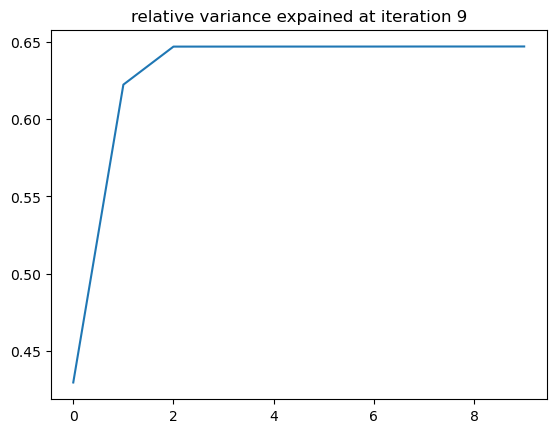

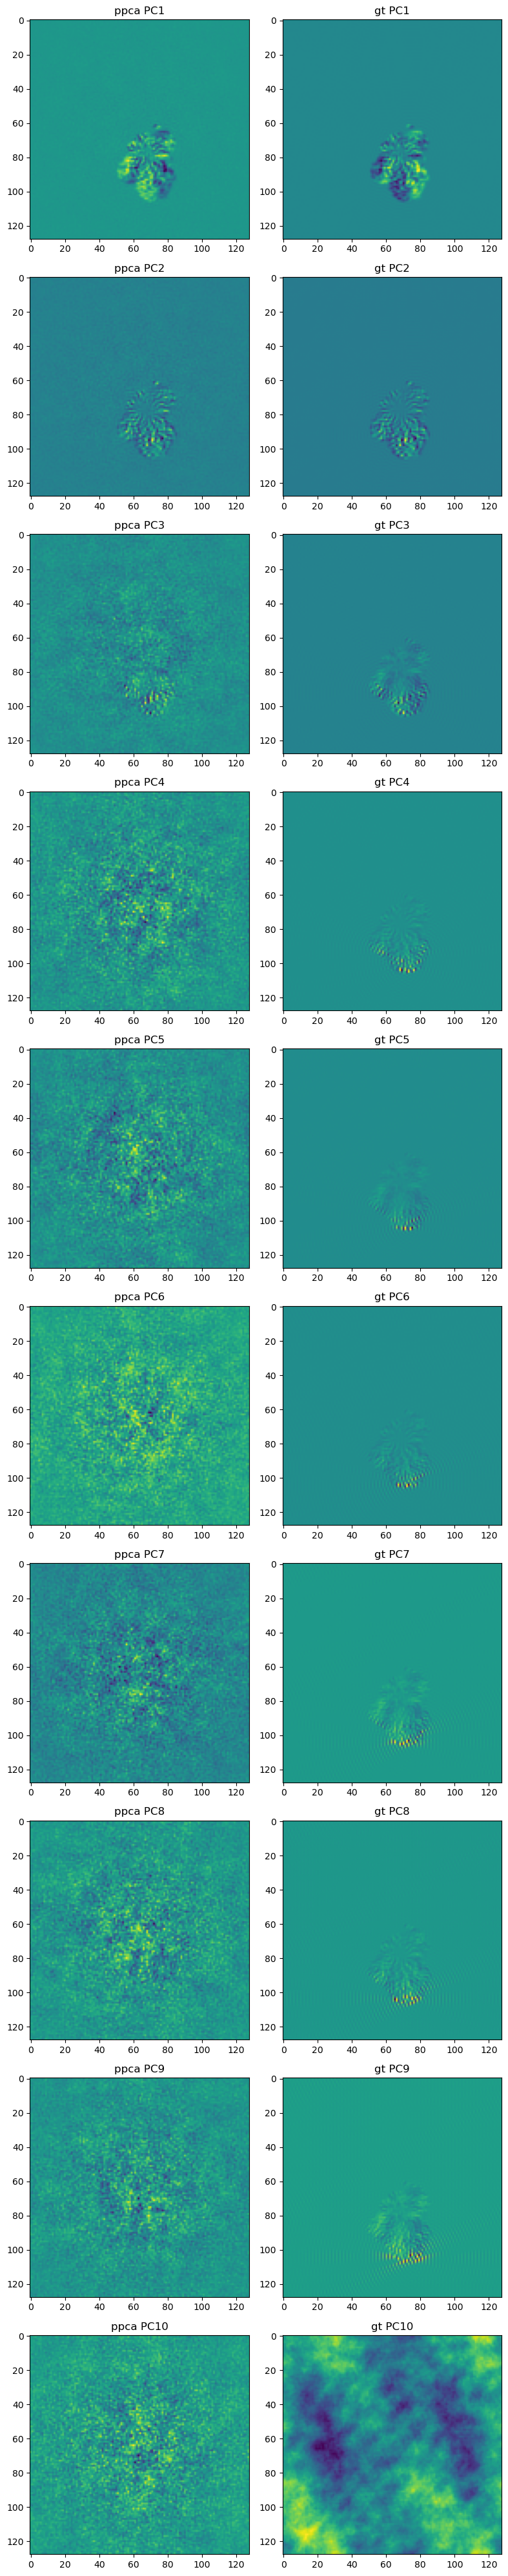

EM ALGORITHM COMPLETED
PPCA EM: 10 iters in 120s
relvar@10 = 0.6471


In [9]:
W_init = jr.normal(jr.PRNGKey(0), (vol_size, N_PCS), dtype=jnp.float32)
W_init = linalg.batch_dft3(W_init, vs, N_PCS)

W_prior = prior_estimation.make_gt_prior_from_variance_total(
    gt.get_fourier_variances(contrasted=False), N_PCS, vs,
)['W_prior']

t0 = time.time()
U_ppca, S_ppca, W_ppca, _, _ = ppca_mod.EM(
    cryo, gt_mean, W_init, W_prior,
    EM_iter=PPCA_ITERS,
    U_gt=U_gt_all, S_gt=s_gt_all,
    disc_type_mean=DISC_TYPE, disc_type=DISC_TYPE,
    contrast_mode='none',
)
dt_ppca = time.time() - t0

rv_ppca = metrics.captured_variance(U_ppca, U_gt_all, s_gt_all)
relvar_ppca = np.asarray(metrics.relative_variance_from_captured_variance(rv_ppca, s_gt_all))
print(f'PPCA EM: {PPCA_ITERS} iters in {dt_ppca:.0f}s')
print(f'relvar@{N_PCS} = {relvar_ppca[-1]:.4f}')

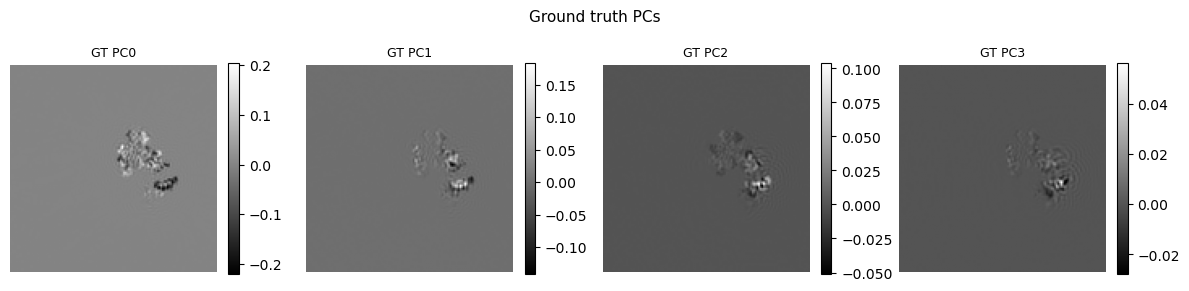

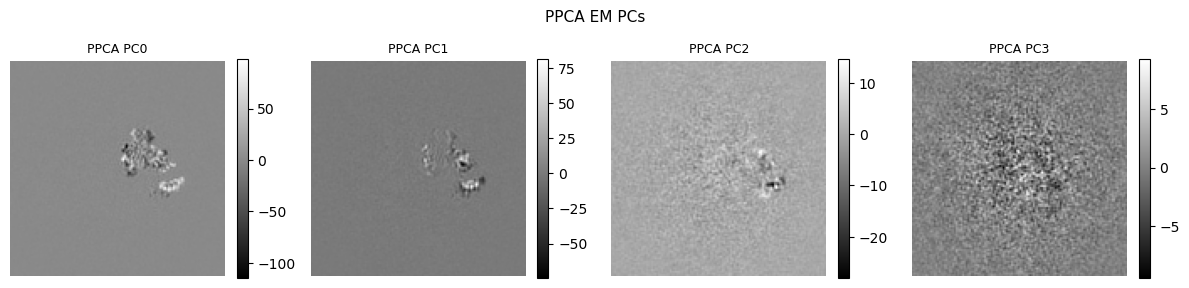

In [10]:
n_show = min(4, N_PCS)
gt_real = [to_real(U_gt_all[:, k] * s_gt_all[k], vs) for k in range(n_show)]
ppca_real = [to_real(U_ppca[:, k] * S_ppca[k], vs) for k in range(n_show)]

plot_slices(gt_real, [f'GT PC{k}' for k in range(n_show)], 'Ground truth PCs')
plot_slices(ppca_real, [f'PPCA PC{k}' for k in range(n_show)], 'PPCA EM PCs')

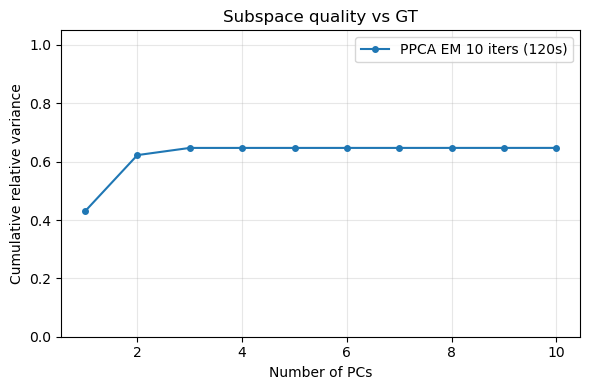

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(relvar_ppca) + 1), relvar_ppca, 'o-',
        label=f'PPCA EM {PPCA_ITERS} iters ({dt_ppca:.0f}s)', markersize=4)
ax.set_xlabel('Number of PCs')
ax.set_ylabel('Cumulative relative variance')
ax.set_title('Subspace quality vs GT')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## API Reference

```python
from recovar.ppca.sketched_normal import compute_normal_residual_sketches

result = compute_normal_residual_sketches(
    cryo,                        # CryoEMDataset with noise model
    U_X_half,                    # (half_vol, rank)
    sigma_X,                     # (rank,)
    V_X,                         # (n_images, rank)
    mean_half,                   # (half_vol,)
    batch_size=500,
    left_sketch_half=S_left,     # (s, half_vol) -> returns (s, n_images)
    right_sketch=Q_right,        # (n_images, t) -> returns (half_vol, t)
)
```

All volumes in **half-volume rfft layout**: `(N, N, N//2+1)` flattened.
Convert with `ftu.full_volume_to_half_volume` / `ftu.half_volume_to_full_volume`.